In [42]:
import matplotlib.pyplot as plt
import json
import numpy as np
from collections import Counter, defaultdict


In [43]:
sessions = []
with open('sessions.jsonl') as f:
    for line in f:
        line = line.strip()
        if line:
            sessions.append(json.loads(line))

unique_sessions=set(map(str,sessions))

# Шаг 1: EDA

### Сессии

In [44]:
print(f"Всего сессий: {len(sessions)}")
print(f"Всего уникальных  сессий: {len(set(unique_sessions))}")
print('Первый 5 сессий')
for ses in sessions[:5]:
    print(ses)


Всего сессий: 2565
Всего уникальных  сессий: 2564
Первый 5 сессий
[380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341, 293]
[53, 54, 53, 65, 53, 335, 286, 335]
[54, 397, 398, 294, 223, 293, 233]
[335, 54, 335, 221, 41, 247, 380, 114, 43, 111, 257, 335, 54, 62, 387, 362, 387]
[252, 301, 387, 212, 246, 61, 175, 392, 370, 233, 92]


In [45]:
repeats_in_a_row = sum(
    1 for s in sessions
    for i in range(len(s)-1) if s[i] == s[i+1]
)
print(f'Повторов подряд: {repeats_in_a_row}')

Повторов подряд: 0


In [46]:
sessions_length = [len(ses) for ses in sessions]
print(f'Средняя продолжительность сессии: {round(np.mean(sessions_length),2)}')
print(f'Медиана продолжительности сессии: {np.median(sessions_length)}')
print(f'Минимальная продолжительность сессии: {np.min(sessions_length)}')
print(f'Максимальная продолжительность сессии: {np.max(sessions_length)}')

Средняя продолжительность сессии: 10.47
Медиана продолжительности сессии: 9.0
Минимальная продолжительность сессии: 3
Максимальная продолжительность сессии: 20


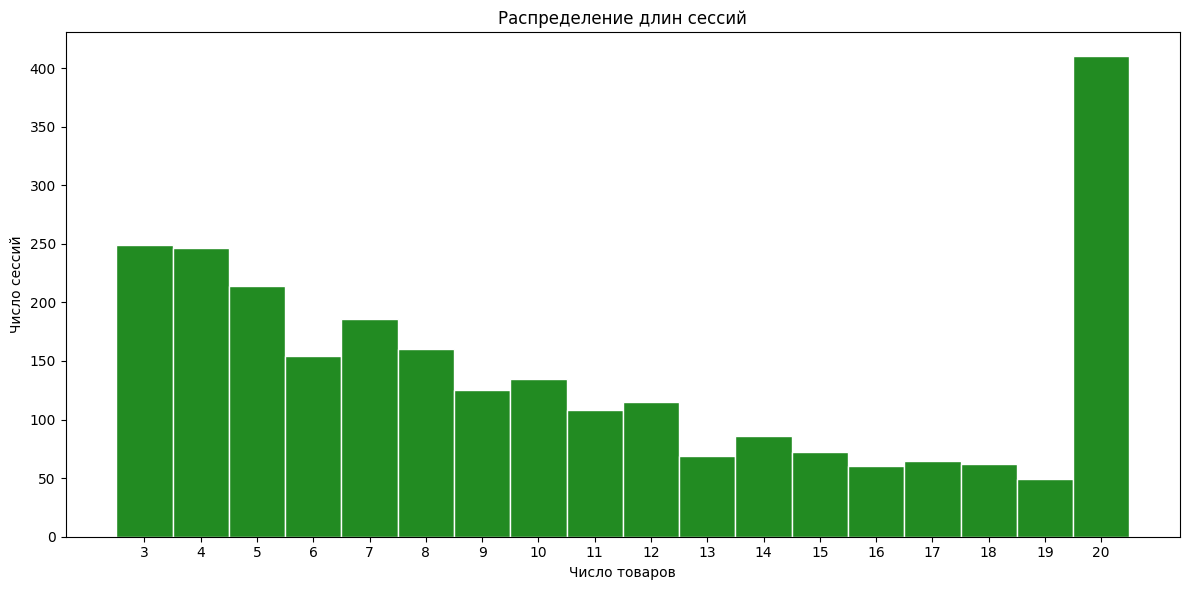

In [47]:
plt.figure(figsize=(12, 6))
plt.hist(sessions_length, bins=range(3, 22), color='#228B22', edgecolor='white', align='left')
plt.title('Распределение длин сессий')
plt.xlabel('Число товаров')
plt.ylabel('Число сессий')
plt.xticks(range(3, 21))
plt.tight_layout()
plt.show()

Анализ: Датасет содержит 2565 сессий (2564 уникальных - одна повторяющиеся). Длина сессий варьируется от 3 до 20 товаров, среднее - 10.5, медиана - 9. Распределение имеет 2 пика: на коротких сессиях (3-4 товара) и на длине 20  вероятно, сессии были усечены до максимума в 20 элементов. Повторов одного товара подряд внутри сессий нет совсем (0 из ~27000 переходов) значит датасет был предобработан.

### Товары

In [48]:
item_counts = Counter(item for s in sessions for item in s)
top20 = item_counts.most_common(20)

In [49]:
print(f'Всего просмотренных товаров: {sum(item_counts.values())}')
print(f'Уникальных товаров: {len(item_counts)}')

Всего просмотренных товаров: 26843
Уникальных товаров: 400


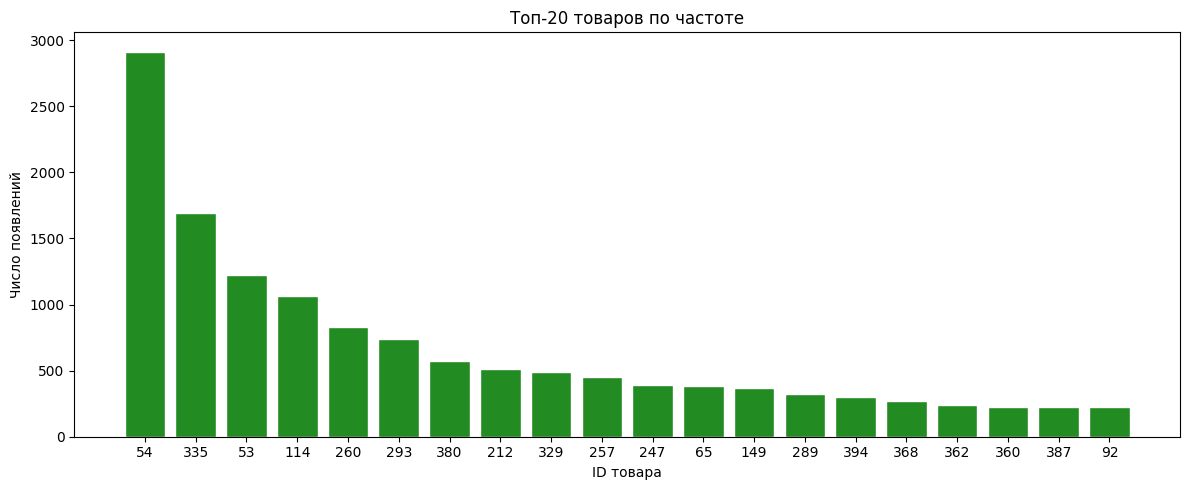

In [50]:
plt.figure(figsize=(12, 5))
plt.bar([str(k) for k,v in top20], [v for k,v in top20], color='#228B22', edgecolor='white')
plt.title('Топ-20 товаров по частоте')
plt.xlabel('ID товара')
plt.ylabel('Число появлений')
plt.tight_layout()
plt.show()

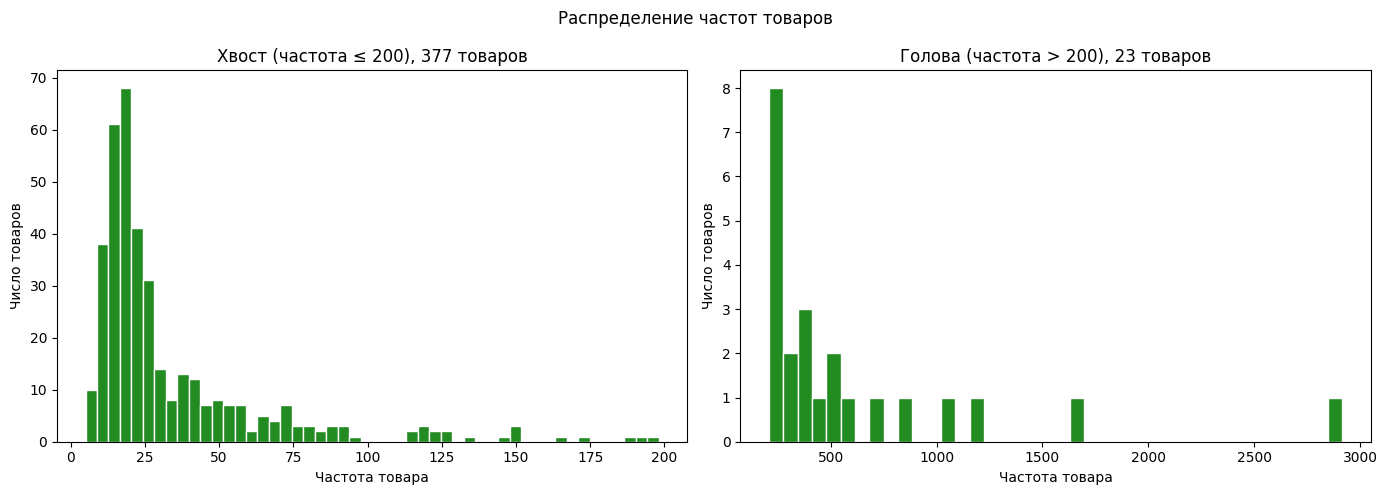

In [51]:
freqs = sorted(item_counts.values(), reverse=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
head_freqs = [f for f in freqs if f <= 200]
ax1.hist(head_freqs, bins=50, color='#228B22', edgecolor='white')
ax1.set_title(f'Хвост (частота ≤ 200), {len(head_freqs)} товаров')
ax1.set_xlabel('Частота товара')
ax1.set_ylabel('Число товаров')

tail_freqs = [f for f in freqs if f > 200]
ax2.hist(tail_freqs, bins=40, color='#228B22', edgecolor='white')
ax2.set_title(f'Голова (частота > 200), {len(tail_freqs)} товаров')
ax2.set_xlabel('Частота товара')
ax2.set_ylabel('Число товаров')

plt.suptitle('Распределение частот товаров')
plt.tight_layout()
plt.show()

In [52]:

once = sum(1 for f in freqs if f == 1)
print(f'Товаров с частотой 1: {once} ({once/len(freqs):.2%})')


rare = sum(1 for f in freqs if f < 10)
print(f'Товаров с частотой < 10: {rare} ({rare/len(freqs):.2%})')

Товаров с частотой 1: 0 (0.00%)
Товаров с частотой < 10: 15 (3.75%)


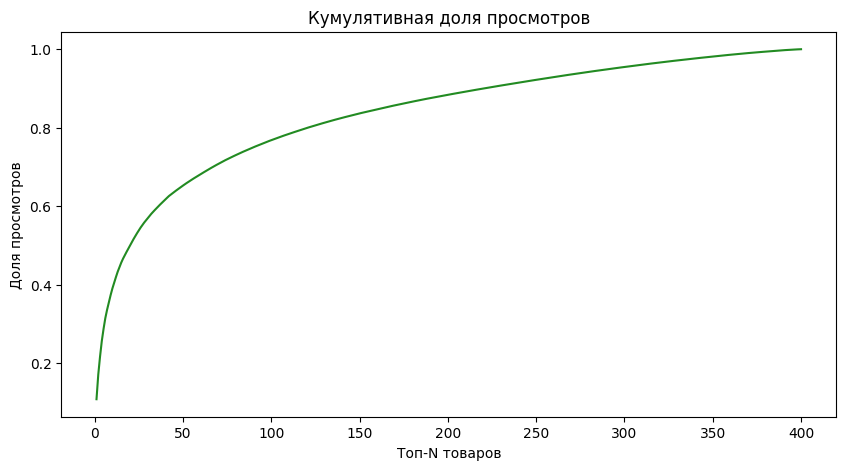

In [53]:
cumsum = np.cumsum(freqs) / sum(freqs)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumsum)+1), cumsum,color='#228B22')
plt.xlabel('Топ-N товаров')
plt.ylabel('Доля просмотров')
plt.title('Кумулятивная доля просмотров')
plt.show()

Анализ: за все сессии было просмотрено почти 27000 товаров, из них всего 400 уникальных (67.5 просмотра на товар в среднем), а товаров просмотренных меньше 10 раз всего 3.75%, однако большая часть товаров (377 из 400) не превысила отметку в 200 просмотров. Самый популярный товар 54 (почти 3000 просмотров), скорее всего именно он будет рекомендован для новых пользователей.

Также можно выделить первые 50 товаров по популярности, так как они составляют более чем 60% от общего числа просмотров.

# Шаг 2: train/test split

In [54]:
def train_test_split(sessions):
    train_sessions = [s[:-1] for s in sessions]
    test_targets = [s[-1] for s in sessions]
    return train_sessions, test_targets

train_sessions, test_targets = train_test_split(sessions)

In [69]:
print(f"Пример: train {train_sessions[4]}, test  {test_targets[4]}")

Пример: train [252, 301, 387, 212, 246, 61, 175, 392, 370, 233], test  92


При разделении данных на тренировочную и тестовую выборки использовался следующий метод: последний товар в сессии: цель для предсказания, все предыдущие товары: история (обучающие данные). Использовался именно такой метод вместо случайного разбиения, так как каждая сессия - это упорядоченная во времени последовательность: при случайном перемешивании модель обучалась бы на будущих переходах той же сессии, что является утечкой данных (data leakage) и приводит к завышенным метрикам. Сплит по последнему элементу имитирует реальное предсказание следующего клика по истории просмотров.

# Шаг 3: Граф переходов

In [56]:
pairs_count=defaultdict(Counter)
for session in train_sessions:
    for i in range(1,len(session)):
        pairs_count[session[i-1]][session[i]] += 1


In [57]:
pairs_count[7]

Counter({149: 3,
         161: 2,
         369: 1,
         92: 1,
         380: 1,
         75: 1,
         258: 1,
         335: 1,
         162: 1,
         347: 1,
         132: 1,
         89: 1,
         114: 1,
         196: 1,
         226: 1,
         293: 1,
         70: 1,
         260: 1})

In [58]:
probabilities=dict()
for item,next_items in pairs_count.items():
    sum_of_neighbours=sum(next_items.values())
    probabilities[item]={ni:c/sum_of_neighbours for ni,c in next_items.items()}

In [68]:
warm_idx = [i for i, s in enumerate(train_sessions) if s[-1] in probabilities]
cold_idx = [i for i, s in enumerate(train_sessions) if s[-1] not in probabilities]

print(f"Просмотренные: {len(warm_idx)}, cold_start: {len(cold_idx)}")

Просмотренные: 2565, cold_start: 0


In [59]:
probabilities[7]

{369: 0.047619047619047616,
 92: 0.047619047619047616,
 380: 0.047619047619047616,
 75: 0.047619047619047616,
 161: 0.09523809523809523,
 258: 0.047619047619047616,
 335: 0.047619047619047616,
 162: 0.047619047619047616,
 347: 0.047619047619047616,
 132: 0.047619047619047616,
 89: 0.047619047619047616,
 114: 0.047619047619047616,
 149: 0.14285714285714285,
 196: 0.047619047619047616,
 226: 0.047619047619047616,
 293: 0.047619047619047616,
 70: 0.047619047619047616,
 260: 0.047619047619047616}

Граф переходов между товарами построен исключительно на train  датасете, чтобы избежать data leakage,  то есть утечки данных(о взаимосвязи между товаром для предсказания и последним товаром в train session) из теста.

Также стоит отметить, что все товары в тренировочных данных покрыты этим графом, то есть нет товаров без связей с другими позициями.

# Шаг 4 : Рекомендательная модель

In [60]:
train_items_counts=Counter(i for s in train_sessions for i in s)
top_popular_items_list=train_items_counts.most_common(10)
top_popular_items_list=[i for i,c in top_popular_items_list]
top_popular_items_list


[54, 335, 53, 114, 260, 293, 380, 212, 329, 257]

In [61]:
def recommend(items_number,probabilities):
    if items_number in probabilities.keys():
        sorted_probs=sorted(probabilities[items_number].items(), key=lambda x: x[1], reverse=True)
        next_items= [i for i,prob in sorted_probs ]


        for pop_items in top_popular_items_list:
            if len(next_items)>=10:
                break
            if pop_items not in next_items:
                next_items.append(pop_items)

        return next_items[:10]

    else:

        return [i for i in top_popular_items_list if i!=items_number][:10]


print(recommend(4,probabilities))

[53, 54, 106, 58, 335, 350, 229, 235, 114, 260]


Рекомендательная система работает следующим образом: на вход подаётся номер последнего просмотренного товара, и если он уже учтён в базе данных, то подбирается топ-10 самых вероятных товаров (вероятности рассчитаны на основе частоты встречания пары товаров). Если не хватает количества взаимодействий или на вход подан новый товар, то топ-10 добирается из 11 самых популярных товаров(чтобы учесть случай если товар не будет иметь связей в probabilities,но будет находится в топе, например, если его всегда смотрели последним)

Дополнительно стоило бы учесть, что товар не должен быть рекомендован следующим для самого себя, однако при анализе данных было выяснено, что в датасете не было повторяющихся подряд товаров при просмотре сессии.

# Шаг 5: оценка качества

In [62]:
def hit_at_k(
    recommendations: list[list[int]],
    true_items: list[int],
    k: int = 10,
) -> float:

    assert len(recommendations) == len(true_items), \
        "recommendations и true_items должны совпадать по длине"

    hits = 0
    for recs, true_item in zip(recommendations, true_items):
        if true_item in recs[:k]:
            hits += 1

    return hits / len(true_items)

In [63]:
recommendations_system=[]

recommendations_baseline=[]
for train_ses in train_sessions:
    result=recommend(train_ses[-1],probabilities)

    recommendations_system.append(result)

    recommendations_baseline.append([i for i in top_popular_items_list if i!=train_ses[-1]][:10])

In [64]:
hit_at_k(recommendations_system, test_targets, 10)

0.5142300194931774

In [65]:
hit_at_k(recommendations_baseline, test_targets, 10)

0.3840155945419103

Для оценки используется метрика Hit@10, которая показывает процент случаев где следующий товар реально попал в топ10 предсказанных системой. Позиция внутри топ-10 не учитывается; если бы она была важна, подошла бы метрика nDCG.
Также, поскольку в данных есть одна повторяющаяся сессия, модель дала одинаковое предсказание для обеих копий, однако это незначительно влияет на результирующую метрику.
Результат: Hit@10 = 0.514, baseline (топ-10 популярных) = 0.384. Модель обходит baseline на 13 пунктов

## Итоги

Реализована рекомендательная система на основе связи между просмотренным товаром и следующим:
 граф переходов между товарами построен на train-сессиях, для
каждого товара хранятся условные вероятности P(j|i) перехода к следующему
товару. Рекомендации - топ-10 соседей последнего просмотренного товара
по убыванию вероятности, при нехватке соседей  список
добирается из топ-популярных товаров train-выборки.

Результаты:
- Hit@10 модели: **0.514**
- Hit@10 popularity-baseline: **0.384**
- Прирост: **+13 пунктов** (относительный +34%)


Сильный popularity-бейзлайн (0.384) согласуется с высокой концентрацией
просмотров: топ-50 товаров покрывают более 60% всех взаимодействий.
 Обнаруженный дубликат
сессии (2564 уникальных из 2565) - небольшой источник шума в Hit@10, но
его влияние мало(<0.0004).

Система показала довольно хороший результат из-за  плотного графа переходов, если  данные были бы разрежены, скорее всего ее результаты деградировали до baseline.


Используется только последний просмотренный товар. Это ограничивает индивидуальность: два пользователя
с одинаковым последним товаром, но разными историями получат идентичные
рекомендации. Такая модель подоходит для мгновенных предсказаний без хранения истории пользователя

Что можно улучшить:
- Скользящее окно: агрегировать вероятности по нескольким последним товарам
  с затухающими весами.
- Переход к эмбеддингам (item2vec), но это выходит за рамки простых моделей.